# Treinamento

As colunas da database são: PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked

### Pré processamneto realizado
    As colunas 'PassengerId',"Name",'Ticket',"Cabin" foram cortadas por serem consideradas ruído ou pouco significativas para o resultado.
    A coluna 'Sex' foi transformada em valor binário
    A coluna 'Embarked' foi transformada em 3 colunas binárias cada uma referente a um dos valores possiveis de onde a pessoa embarcou.

### Modelo usado
    O xgboost foi usado como modelo caixa preta que cria uma série de arvores de decisão (Tradicionalmente considerados caixa branca) e usa o resultado dessas arvores para tomar uma decisão, de modo que a sáida é matematicamente complexa o suficiente para ser humamente dificil explicar.

### Hiperparametros
    A taxa de aprendizado é de 0.1 e a profundidade da árvore é de 5. Outras combinações de valores foram tentadas mas essa atingiu o maior resultado em termos de acurácia (0.8182).
    _Obs_: Usando os parametros padrão do xgboost a acurácia foi de 0.7622

### Valores alterados
    Houveram tentativas de ajuste menores, como cortar outras colunas, mas todas as combinações e variações diferentes das que estão na célula abaixo apresentaram redução na acurácia.
    

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

dataset = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(dataset)

print("=== Estrutura do Dataset ===")
df.info()

print("\n=== Primeiras 5 linhas ===")
print(df.head())

print("\n=== Estatísticas Descritivas ===")
print(df.describe())

print("\n=== Valores ausentes por coluna ===")
print(df.isnull().sum())

print("\nDimensão original:", df.shape)

=== Estrutura do Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== Primeiras 5 linhas ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4      

max_depth=2 -> Acurácia: 0.7972
max_depth=3 -> Acurácia: 0.7972
max_depth=4 -> Acurácia: 0.7972
max_depth=5 -> Acurácia: 0.8182
max_depth=6 -> Acurácia: 0.8112
max_depth=7 -> Acurácia: 0.8112
max_depth=8 -> Acurácia: 0.7902


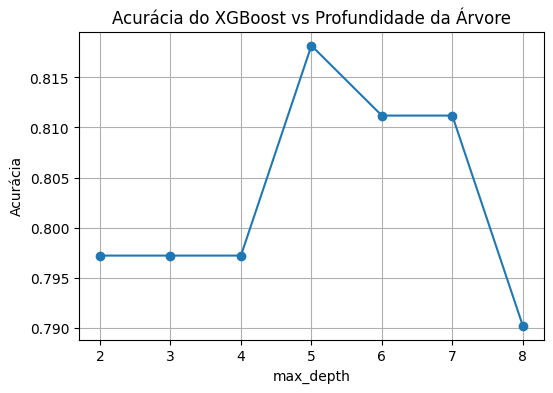

In [59]:
max_depth_values = [2, 3, 4, 5, 6, 7, 8]
accuracies = []

for depth in max_depth_values:
    
    model = xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=depth
    )
    
    model.fit(X_train, y_train)
    
    accuracy = model.score(X_test, y_test)
    accuracies.append(accuracy)

    print(f"max_depth={depth} -> Acurácia: {accuracy:.4f}")

plt.figure(figsize=(6,4))

plt.plot(max_depth_values, accuracies, marker='o')

plt.xlabel("max_depth")
plt.ylabel("Acurácia")
plt.title("Acurácia do XGBoost vs Profundidade da Árvore")

plt.grid(True)

plt.show()

learning_rate=0.01 -> Acurácia: 0.7832
learning_rate=0.05 -> Acurácia: 0.7762
learning_rate=0.1 -> Acurácia: 0.8182
learning_rate=0.2 -> Acurácia: 0.7832
learning_rate=0.3 -> Acurácia: 0.7762
learning_rate=0.4 -> Acurácia: 0.7552


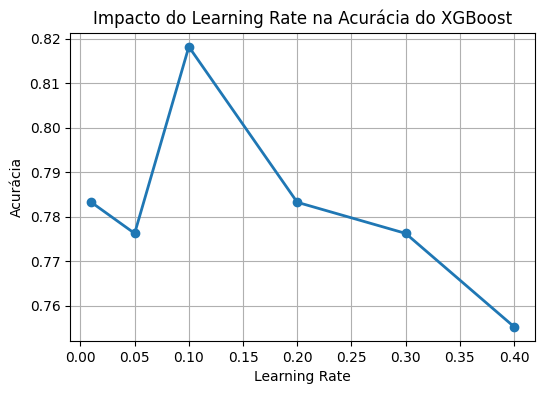

In [60]:
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]
accuracies = []

for lr in learning_rates:

    model = xgb.XGBClassifier(
        learning_rate=lr,
        max_depth=5,
        eval_metric='logloss'
    )

    model.fit(X_train, y_train)

    accuracy = model.score(X_test, y_test)
    accuracies.append(accuracy)

    print(f"learning_rate={lr} -> Acurácia: {accuracy:.4f}")

plt.figure(figsize=(6,4))

plt.plot(learning_rates, accuracies, marker='o', linewidth=2)

plt.xlabel("Learning Rate")
plt.ylabel("Acurácia")
plt.title("Impacto do Learning Rate na Acurácia do XGBoost")

plt.grid(True)

plt.show()

In [61]:
df = df.drop(['PassengerId', "Name", 'Ticket', "Cabin"], axis=1).dropna()

print("\nDimensão após limpeza:", df.shape)

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df = pd.get_dummies(df, columns=['Embarked'])

print("\n=== Dataset após pré-processamento ===")
print(df.head())

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTamanho treino:", X_train.shape)
print("Tamanho teste:", X_test.shape)

model = xgb.XGBClassifier(learning_rate=0.1,max_depth=5)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"Acurácia: {accuracy:.4f}")


Dimensão após limpeza: (712, 8)

=== Dataset após pré-processamento ===
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_C  Embarked_Q  \
0         0       3    1  22.0      1      0   7.2500       False       False   
1         1       1    0  38.0      1      0  71.2833        True       False   
2         1       3    0  26.0      0      0   7.9250       False       False   
3         1       1    0  35.0      1      0  53.1000       False       False   
4         0       3    1  35.0      0      0   8.0500       False       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  

Tamanho treino: (569, 9)
Tamanho teste: (143, 9)
Acurácia: 0.8182


### SLM
O bloco abaixo é responsável por conectar com o SLM qwen2.5 rodando localmente.
Antes de executar esse bloco é importante ter o SLM rodando na sua maquina:

#### Via docker
> docker model run ai/qwen2.5

#### Via Ollama
Caso você tenha rodado o projeto com:
> docker compose -f docker-compose.yml -f docker-compose-ollama.yml up -d

Você pode rodar o modelo pelo ollama com o comando:
> docker compose exec qwen_slm ollama run qwen2.5

In [62]:
import os
import requests

_QWEN_WORKING_URL = None

def get_qwen_url():
    global _QWEN_WORKING_URL
    
    if _QWEN_WORKING_URL:
        return _QWEN_WORKING_URL
        
    print("Buscando a URL do Qwen...")
    url_env = os.getenv("QWEN_URL")
    urls_para_testar = [url_env] if url_env else []
    
    urls_para_testar.extend( [
        "http://qwen_slm:11434/api/generate",
        "http://qwen:11434/api/generate",
        "http://host.docker.internal:11434/api/generate",
        "http://localhost:11434/api/generate",
        "http://127.0.0.1:11434/api/generate"
    ])
    
    teste_payload = {"model": "qwen2.5", "prompt": "teste", "stream": False}
    
    for url in urls_para_testar:
        try:
            resposta = requests.post(url, json=teste_payload, timeout=30)
            if resposta.status_code == 200:
                _QWEN_WORKING_URL = url
                return _QWEN_WORKING_URL
        except requests.exceptions.RequestException:
            continue
            
    raise ConnectionError("Erro Crítico: Não encontrei o modelo Qwen em nenhuma das rotas.")

def ask_qwen(prompt):
    url = get_qwen_url()
    
    payload = {
        "model": "qwen2.5", 
        "prompt": prompt,
        "stream": False
    }
    
    try:
        resposta = requests.post(url, json=payload, timeout=30)
        if resposta.status_code == 200:
            return resposta.json().get("response", "").strip()
        else:
            return f"Erro na API: Status {resposta.status_code}"
    except requests.exceptions.RequestException as e:
        return f"Erro de conexão: {e}"

In [63]:
import numpy as np

PROMPT_BASE = """Você é um especialista em análise de dados avaliando a sobrevivência de passageiros do Titanic.

DICIONÁRIO DE DADOS:
- Pclass: 1 = 1ª Classe, 2 = 2ª Classe, 3 = 3ª Classe.
- Sex: 0 = Mulher, 1 = Homem.
- Age: Idade em anos.
- SibSp: Número de irmãos/cônjuges a bordo.
- Parch: Número de pais/filhos a bordo.
- Fare: Tarifa paga.
- Embarked_C, Embarked_Q, Embarked_S: Valor 1.0 indica o porto de embarque.

DIRETRIZES DE EXPLICABILIDADE (SHAP):
- Valores SHAP > 0: Contribuem para a predição de sobrevivência.
- Valores SHAP < 0: Contribuem para a predição de não sobrevivência (óbito).
- A magnitude absoluta indica a força da influência da variável.

DADOS DA INSTÂNCIA E VALORES SHAP:
{detalhes}

INSTRUÇÃO:
Com base estritamente no dicionário de dados e nos valores SHAP fornecidos, escreva um parágrafo conciso explicando os principais fatores que determinaram a predição para este passageiro. Inicie o texto informando a predição final (sobreviveu ou morreu). Utilize linguagem natural, omitindo os valores numéricos e os nomes técnicos das variáveis."""

PROMPT_SINTESE = """Você é um especialista em análise de dados. Abaixo estão 5 explicações locais geradas por um método de explicabilidade sob restrição computacional.

{textos_combinados}

INSTRUÇÃO:
Analise as 5 explicações. Identifique os determinantes de consenso e descarte as flutuações e contradições. Escreva um parágrafo único, fluido e definitivo, sintetizando a motivação real para a predição deste passageiro."""

def extrair_valores_shap(shap_output):
    valores_brutos = np.array(shap_output)
    if valores_brutos.ndim == 3:
        return valores_brutos[0, :, 1]
    elif isinstance(shap_output, list):
        return shap_output[1][0]
    return valores_brutos[0]

def formatar_detalhes(valores_shap, valores_reais, colunas):
    exp = [(colunas[i], float(valores_shap[i])) for i in range(len(colunas))]
    exp_ordenada = sorted(exp, key=lambda x: abs(x[1]), reverse=True)
    return "\n".join([f"- {feat} (Valor real: {valores_reais.get(feat)}): Peso SHAP = {val:.4f}" for feat, val in exp_ordenada])

### Seleciona um passageiro e pega os valores de Shap dele.
São criadas 5 grupos de valores diferentes, cada um deles gerado usando um numero de exemplos diferentes. (Pode ser variado modificando valores na lista nsamples_lista alterando n na chamada na função explainer.shap_values, ex: nsamples=n*5). 

In [64]:
import shap
import time

indice_passageiro = 0
instancia = X_test.iloc[indice_passageiro:indice_passageiro+1]
valores_reais = instancia.to_dict(orient='records')[0]
colunas_train = X_train.columns

print(f"--- Dados do Passageiro (Índice {indice_passageiro}) ---")
for coluna, valor in valores_reais.items():
    print(f"  {coluna}: {valor}")
print("-" * 50 + "\n")

background = shap.sample(X_train, 10)

def predict_fn(X):
    return model.predict_proba(X)

explainer = shap.KernelExplainer(predict_fn, background)

nsamples_lista = [10, 15, 20, 25, 30]

explicacoes_pobres = []
tempos_shap = []

for n in nsamples_lista:

    inicio = time.time()

    shap_values_ruido = explainer.shap_values(instancia,nsamples=n*5,silent=True)

    fim = time.time()
    tempo_exec = fim - inicio
    tempos_shap.append(tempo_exec)

    valores_shap = extrair_valores_shap(shap_values_ruido)

    exp_formatada = [
        (colunas_train[i], float(valores_shap[i]))
        for i in range(len(colunas_train))
    ]

    explicacoes_pobres.append(exp_formatada)

for idx, exp in enumerate(explicacoes_pobres):

    print(f"--- Explicação {idx+1} (nsamples={nsamples_lista[idx]*5}) ---")
    print(f"Tempo SHAP: {tempos_shap[idx]:.4f} s")

    exp_ordenada = sorted(exp, key=lambda x: abs(x[1]), reverse=True)

    for feature, valor in exp_ordenada:
        print(f"  {feature}: {valor:.4f}")

    print()

--- Dados do Passageiro (Índice 0) ---
  Pclass: 1
  Sex: 0
  Age: 24.0
  SibSp: 0
  Parch: 0
  Fare: 69.3
  Embarked_C: True
  Embarked_Q: False
  Embarked_S: False
--------------------------------------------------

--- Explicação 1 (nsamples=50) ---
Tempo SHAP: 0.0270 s
  Sex: 0.3351
  Pclass: 0.0789
  Age: -0.0346
  Fare: 0.0237
  Parch: -0.0157
  SibSp: 0.0083
  Embarked_C: 0.0050
  Embarked_S: 0.0018
  Embarked_Q: 0.0000

--- Explicação 2 (nsamples=75) ---
Tempo SHAP: 0.0270 s
  Sex: 0.3370
  Pclass: 0.0845
  Age: -0.0495
  Fare: 0.0289
  SibSp: -0.0115
  Embarked_C: 0.0064
  Embarked_S: 0.0062
  Parch: 0.0005
  Embarked_Q: 0.0000

--- Explicação 3 (nsamples=100) ---
Tempo SHAP: 0.0150 s
  Sex: 0.3440
  Pclass: 0.0780
  Age: -0.0431
  Fare: 0.0201
  Embarked_C: 0.0055
  Parch: -0.0051
  SibSp: 0.0015
  Embarked_S: 0.0015
  Embarked_Q: 0.0000

--- Explicação 4 (nsamples=125) ---
Tempo SHAP: 0.0137 s
  Sex: 0.3434
  Pclass: 0.0780
  Age: -0.0428
  Fare: 0.0229
  Parch: -0.0143
  Em

In [65]:
textos_pobres = []
tempos_explicacao = []

for idx, exp in enumerate(explicacoes_pobres):

    inicio = time.perf_counter()

    valores_shap = [valor for _, valor in exp]

    texto_detalhes = formatar_detalhes(valores_shap,valores_reais,colunas_train)

    prompt_slm = PROMPT_BASE.format(detalhes=texto_detalhes)
    
    resposta_qwen = ask_qwen(prompt_slm)

    fim = time.perf_counter()

    tempo = fim - inicio
    tempos_explicacao.append(tempo)

    textos_pobres.append(resposta_qwen)

for idx, texto in enumerate(textos_pobres):

    print(f"--- Explicação Textual {idx+1} ---")
    print(f"Tempo: {tempos_explicacao[idx]:.4f} s")
    print(texto)
    print()

Buscando a URL do Qwen...
--- Explicação Textual 1 ---
Tempo: 45.4116 s
O passageiro predito como sobrevivente. O fato de ser uma mulher, a bordagem no porto C, e a classe econômica da passagem contribuíram positivamente para a predição de sobrevivência. A idade mais avançada em comparação com os demais passageiros e o valor da passagem mais alto também apoiaram essa previsão. Embora os passageiros com irmãos ou pais a bordo tenham ligeiramente diminuído as chances de sobrevivência, este efeito foi compensado pelas outras influências positivas.

--- Explicação Textual 2 ---
Tempo: 22.7934 s
O passageiro, que era uma mulher e viajava na 1ª classe, teve uma predição positiva para a sobrevivência. Sua condição de ser mulher contribuiu significativamente para a predição, bem como o fato de estar viajando na 1ª classe. A idade de 24 anos e a tarifa mais alta de 69.3 não exerceram grande influência na predição, embora a idade tenha ligeiramente diminuído a probabilidade de sobrevivência. Não

In [69]:
import os
from dotenv import load_dotenv
from google import genai

load_dotenv()
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

textos_combinados = "\n\n".join([f"Explicação {i+1}:\n{texto}" for i, texto in enumerate(textos_pobres)])
prompt_sintese_final = PROMPT_SINTESE.format(textos_combinados=textos_combinados)

print("Iniciando a síntese com o Qwen local...\n")
explicacao_forte_qwen = ask_qwen(prompt_sintese_final)
print("=== SÍNTESE (QWEN SLM) ===")
print(explicacao_forte_qwen)
print("\n" + "="*50 + "\n")

print("Iniciando a síntese com a API do Gemini...\n")
resposta_gemini = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=prompt_sintese_final
)
print("=== SÍNTESE (GEMINI LLM) ===")
print(resposta_gemini.text)

Iniciando a síntese com o Qwen local...

=== SÍNTESE (QWEN SLM) ===
Este passageiro foi predito como sobrevivente, principalmente devido à sua condição de ser uma mulher e a classe de 1ª classe em que viajava. O sexo feminino e o fator classe de 1ª classe são determinantes consistentes na predição positiva de sobrevivência, contribuindo significativamente para a chance de sobrevivência. A idade de 24 anos, embora ligeiramente reduza as chances de sobrevivência, não impede a previsão. O embarque no porto C também teve um impacto positivo, embora muito pequeno, mantendo-se em linha com as observações gerais. A ausência de parentes a bordo não afetou negativamente a predição, mantendo a consistência das outras influências positivas.


Iniciando a síntese com a API do Gemini...

=== SÍNTESE (GEMINI LLM) ===
Como especialista em análise de dados, após revisar as explicações fornecidas e descartar as instâncias de erro de conexão e as contradições/flutuações, a motivação real para a predição

## NOVAS METRICAS PARA VALIDAÇÃO

No bloco abaixo verificamos oque seria uma resposta "boa", onde um LLM (no nosso caso, o gemini) usa os valores de shap criados com 2000 samples. 

=== SHAP COMPLETO (BASELINE) ===
--- Explicação Baseline (nsamples=2000) ---
Tempo SHAP: 0.3784 s
  Sex: 0.3397
  Pclass: 0.0796
  Age: -0.0404
  Fare: 0.0230
  Parch: -0.0125
  Embarked_C: 0.0079
  Embarked_S: 0.0077
  SibSp: -0.0025
  Embarked_Q: 0.0000

=== TABELA COMPARATIVA ===


,Tipo,nsamples,Tempo_SHAP (s),Correlação (Spearman)
0,Cheap 1,50,0.0270,0.9000
1,Cheap 2,75,0.0270,0.9500
2,Cheap 3,100,0.0150,0.9500
3,Cheap 4,125,0.0137,0.9833
4,Cheap 5,150,0.0158,0.9667
5,Baseline,2000,0.3784,1.0000


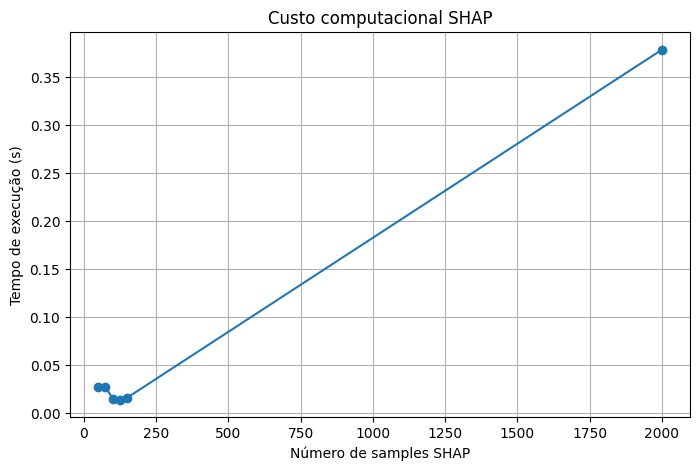

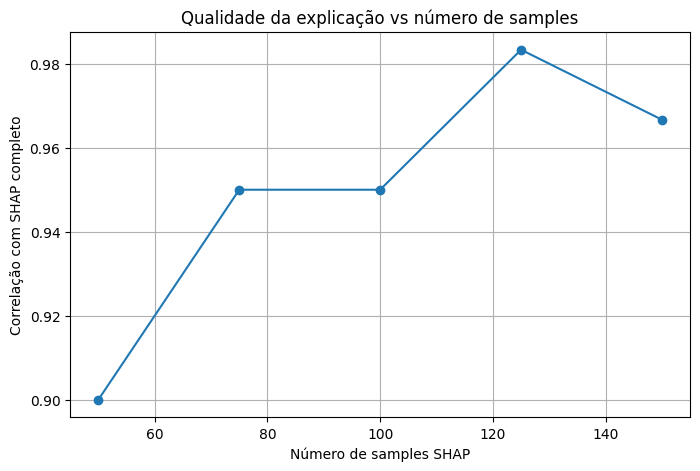

In [75]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

print("=== SHAP COMPLETO (BASELINE) ===")

inicio = time.perf_counter()

shap_values_completo = explainer.shap_values(
    instancia,
    nsamples=2000,
    silent=True
)

fim = time.perf_counter()
tempo_shap_completo = fim - inicio

valores_completos = extrair_valores_shap(shap_values_completo)

exp_completa = [
    (colunas_train[i], float(valores_completos[i]))
    for i in range(len(colunas_train))
]

print(f"--- Explicação Baseline (nsamples=2000) ---")
print(f"Tempo SHAP: {tempo_shap_completo:.4f} s")

exp_ordenada = sorted(exp_completa, key=lambda x: abs(x[1]), reverse=True)

for feature, valor in exp_ordenada:
    print(f"  {feature}: {valor:.4f}")

correlacoes = []

valores_baseline = [valor for _, valor in exp_completa]

for exp in explicacoes_pobres:

    valores_exp = [valor for _, valor in exp]

    corr, _ = spearmanr(valores_exp, valores_baseline)

    correlacoes.append(corr)

dados_tabela = []

for i, tempo in enumerate(tempos_shap):

    dados_tabela.append({
        "Tipo": f"Cheap {i+1}",
        "nsamples": nsamples_lista[i]*5,
        "Tempo_SHAP (s)": round(tempo, 4),
        "Correlação (Spearman)": round(correlacoes[i], 4)
    })

dados_tabela.append({
    "Tipo": "Baseline",
    "nsamples": 2000,
    "Tempo_SHAP (s)": round(tempo_shap_completo, 4),
    "Correlação (Spearman)": 1.0
})

tabela = pd.DataFrame(dados_tabela)

print("\n=== TABELA COMPARATIVA ===")
display(tabela)

nsamples_plot = [n*5 for n in nsamples_lista] + [2000]
tempos_plot = tempos_shap + [tempo_shap_completo]

plt.figure(figsize=(8,5))

plt.plot(nsamples_plot, tempos_plot, marker='o')

plt.xlabel("Número de samples SHAP")
plt.ylabel("Tempo de execução (s)")
plt.title("Custo computacional SHAP")

plt.grid(True)

plt.show()

nsamples_plot_corr = [n*5 for n in nsamples_lista]

plt.figure(figsize=(8,5))

plt.plot(nsamples_plot_corr, correlacoes, marker='o')

plt.xlabel("Número de samples SHAP")
plt.ylabel("Correlação com SHAP completo")
plt.title("Qualidade da explicação vs número de samples")

plt.grid(True)

plt.show()

--- Métrica de Variância (Desvio Padrão sob Restrição) ---
  SibSp: 0.0072
  Parch: 0.0063
  Age: 0.0048
  Embarked_S: 0.0045
  Sex: 0.0035
  Fare: 0.0030
  Pclass: 0.0027
  Embarked_C: 0.0021
  Embarked_Q: 0.0000


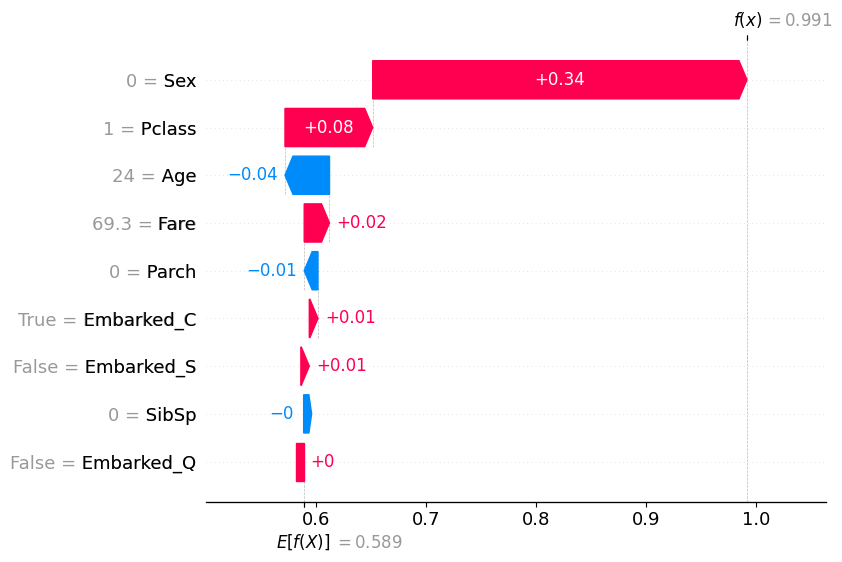


Iniciando a explicação do Baseline com a API do Gemini...

=== EXPLICAÇÃO DO BASELINE (SHAP 2000 + GEMINI) ===
A predição final para este passageiro é de sobrevivência. Os principais fatores que contribuíram positivamente para essa predição foram o fato de ser mulher e estar na primeira classe. A tarifa paga e o porto de embarque também adicionaram uma contribuição positiva. Por outro lado, a sua idade e a ausência de familiares próximos (pais/filhos ou irmãos/cônjuges) a bordo foram fatores que contribuíram negativamente, embora com menor força, para a probabilidade de sobrevivência.


In [76]:
import matplotlib.pyplot as plt

valores_por_feature = {feat: [] for feat in colunas_train}
for exp in explicacoes_pobres:
    for feat, val in exp:
        valores_por_feature[feat].append(val)

print("--- Métrica de Variância (Desvio Padrão sob Restrição) ---")
desvios = []
for feat, valores in valores_por_feature.items():
    desvio = np.std(valores)
    desvios.append((feat, desvio))

desvios_ordenados = sorted(desvios, key=lambda x: x[1], reverse=True)
for feat, desvio in desvios_ordenados:
    print(f"  {feat}: {desvio:.4f}")

shap_values_completo = explainer.shap_values(instancia, nsamples=2000, silent=True)
valores_completos = extrair_valores_shap(shap_values_completo)

base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) > 1 else explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[0]

explicacao_obj = shap.Explanation(
    values=valores_completos,
    base_values=base_val,
    data=instancia.iloc[0].values,
    feature_names=colunas_train
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explicacao_obj, max_display=10, show=True)

texto_detalhes_completo = formatar_detalhes(valores_completos, valores_reais, colunas_train)
prompt_baseline = PROMPT_BASE.format(detalhes=texto_detalhes_completo)

print("\nIniciando a explicação do Baseline com a API do Gemini...\n")
resposta_baseline = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=prompt_baseline
)

print("=== EXPLICAÇÃO DO BASELINE (SHAP 2000 + GEMINI) ===")
print(resposta_baseline.text)

In [79]:
indices_para_testar = [17, 42, 89]

for idx_pass in indices_para_testar:
    print(f"\n{'='*70}\nAVALIAÇÃO DA INSTÂNCIA {idx_pass} (X_test)\n{'='*70}")
    
    instancia_loop = X_test.iloc[idx_pass:idx_pass+1]
    valores_reais_loop = instancia_loop.to_dict(orient='records')[0]
    
    textos_pobres_loop = []
    for n in nsamples_lista:
        shap_values_ruido = explainer.shap_values(instancia_loop, nsamples=n*5, silent=True)
        valores_shap = extrair_valores_shap(shap_values_ruido)
        texto_detalhes = formatar_detalhes(valores_shap, valores_reais_loop, colunas_train)
        prompt_slm = PROMPT_BASE.format(detalhes=texto_detalhes)
        textos_pobres_loop.append(ask_qwen(prompt_slm))

    textos_combinados_loop = "\n\n".join([f"Explicação {i+1}:\n{t}" for i, t in enumerate(textos_pobres_loop)])
    prompt_sintese_loop = PROMPT_SINTESE.format(textos_combinados=textos_combinados_loop)
    resposta_sintese = client.models.generate_content(model='gemini-2.5-flash', contents=prompt_sintese_loop)

    shap_values_comp = explainer.shap_values(instancia_loop, nsamples=2000, silent=True)
    valores_shap_comp = extrair_valores_shap(shap_values_comp)
    texto_detalhes_comp = formatar_detalhes(valores_shap_comp, valores_reais_loop, colunas_train)
    
    prompt_baseline_loop = PROMPT_BASE.format(detalhes=texto_detalhes_comp)
    resposta_baseline = client.models.generate_content(model='gemini-2.5-flash', contents=prompt_baseline_loop)

    print(">>> SÍNTESE LLM (Restrição Computacional):")
    print(resposta_sintese.text.strip())
    print("\n>>> BASELINE LLM (SHAP Estabilizado):")
    print(resposta_baseline.text.strip())


AVALIAÇÃO DA INSTÂNCIA 17 (X_test)
>>> SÍNTESE LLM (Restrição Computacional):
Com base nas explicações válidas (2, 4 e 5), a predição de que este passageiro não sobreviveu é firmemente estabelecida e consistentemente atribuída a determinantes claros. Os fatores preponderantes para essa predição foram o fato de o passageiro ser **homem** e ter viajado na **terceira classe**, ambos com um peso negativo significativo e concordante nas chances de sobrevivência. Contribuíram secundariamente para essa conclusão a **idade avançada** do passageiro e a **ausência de parentes a bordo**, que também apresentaram influências negativas. Embora a **tarifa paga** tenha gerado um efeito positivo marginal, indicando uma ligeira vantagem, sua influência não foi suficiente para contrariar o predomínio das variáveis negativas mais fortes. O porto de embarque, quando mencionado, teve um impacto mínimo ou insignificante na predição final.

>>> BASELINE LLM (SHAP Estabilizado):
A predição para este passageir